# About

This notebook is for machine learning related experimentation.

## Imports

In [1]:
import pandas as pd
from src.preprocessing.validator import validate_schema, validate_rules
from src.preprocessing.result import ValidationResult
from src.core.config import load_validation_schema, load_validation_rules, load_cleaning_configuration
from src.ml.random_forest import RandomForest
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from src.preprocessing.cleaning import clean
from src.dataset.loader import load_cicids2017_dataset
from pathlib import Path
from src.preprocessing.preprocessing import PreprocessingPipeline, initial_cleanup

# Loading Dataset

In [2]:
dataset_dir = '../dataset'

df = load_cicids2017_dataset(dataset_dir)

## Validation and Cleaning

In [3]:
sp = Path('../config/preprocessing/validation_shema.yaml')
schema_cfg = load_validation_schema(sp)

rp = Path('../config/preprocessing/validation_rules.yaml')
rules_cfg = load_validation_rules(rp)

cleaning_path = Path('../config/preprocessing/cleaning.yaml')
cleaning_cfg = load_cleaning_configuration(cleaning_path)

preprocess = PreprocessingPipeline(schema_cfg, rules_cfg, cleaning_cfg)

df = initial_cleanup(df)

preprocess.validate(df)
df = preprocess.clean(df)

preprocess.validate(df)
df = preprocess.clean(df)

preprocess.validate(df)

print(preprocess.validation_result[f'validation_result_{len(preprocess.validation_result)}'])

Validation Result
----------------------
Repairable: 0
Non-repairable: 0
NaN*: 0
Inf*: 0
Negative*: 0
Out Of range*: 0
Rule violators: {'R001': np.int64(0), 'R002': np.int64(0), 'R003': np.int64(0), 'R004': np.int64(0), 'R005': np.int64(0), 'R006': np.int64(0), 'R007': np.int64(0), 'R008': np.int64(0), 'R009': np.int64(0), 'R010': np.int64(0), 'R011': np.int64(0), 'R012': np.int64(0), 'R013': np.int64(0), 'R014': np.int64(0), 'R015': np.int64(0), 'R016': np.int64(0), 'R017': np.int64(0), 'R018': np.int64(0), 'R019': np.int64(0)}
----------------------
NOTE: those marked with * are showing individual cell value count, not row.
Just so you know, a single row can have multiple NaN, Inf, Negative etc. values.


In [4]:
cols_to_drop = [
    'Bwd PSH Flags',
    'Bwd URG Flags',
    'Fwd Avg Bytes/Bulk',
    'Fwd Avg Packets/Bulk',
    'Fwd Avg Bulk Rate',
    'Bwd Avg Bytes/Bulk',
    'Bwd Avg Packets/Bulk',
    'Bwd Avg Bulk Rate',
    "Fwd Header Length.1"
]

df.drop(columns=cols_to_drop, inplace=True)

## Machine Learning

In [5]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(df["Label"])
x = df.drop(columns='Label')

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [6]:
model = RandomForest()
model.fit(x_train, y_train)

In [7]:
out_data_path = Path('../out/data/')
out_data_path.mkdir(exist_ok=True, parents=True)

importance_df = (
    pd.DataFrame({
        "Feature": x.columns,
        "Importance": model.model.feature_importances_
    })
    .sort_values("Importance", ascending=False)
)

importance_df.to_csv(
    Path(out_data_path, "Feature Importance RF.csv"),
    index=False
)

print(importance_df)

                   Feature    Importance
13   Bwd Packet Length Std  7.001646e-02
40  Packet Length Variance  5.905592e-02
39       Packet Length Std  5.878002e-02
52    Avg Bwd Segment Size  4.660364e-02
12  Bwd Packet Length Mean  4.431356e-02
..                     ...           ...
42          SYN Flag Count  3.112972e-04
47          CWE Flag Count  1.002639e-06
31           Fwd URG Flags  5.888435e-07
43          RST Flag Count  1.641139e-08
48          ECE Flag Count  0.000000e+00

[69 rows x 2 columns]


Accuracy: 1.00

Classification Report:
                             precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    417629
                      DDoS       0.91      0.77      0.84       390
                  PortScan       1.00      1.00      1.00     24882
                       Bot       0.99      0.99      0.99      1789
              Infiltration       1.00      1.00      1.00     32343
  Web Attack - Brute Force       0.99      0.99      0.99       966
          Web Attack - XSS       1.00      0.99      0.99       965
Web Attack - Sql Injection       1.00      1.00      1.00      1186
               FTP-Patator       1.00      1.00      1.00         1
               SSH-Patator       1.00      0.86      0.92         7
             DoS slowloris       0.99      0.99      0.99     18112
          DoS Slowhttptest       1.00      1.00      1.00       643
                  DoS Hulk       0.74      0.80      0.77       294
       

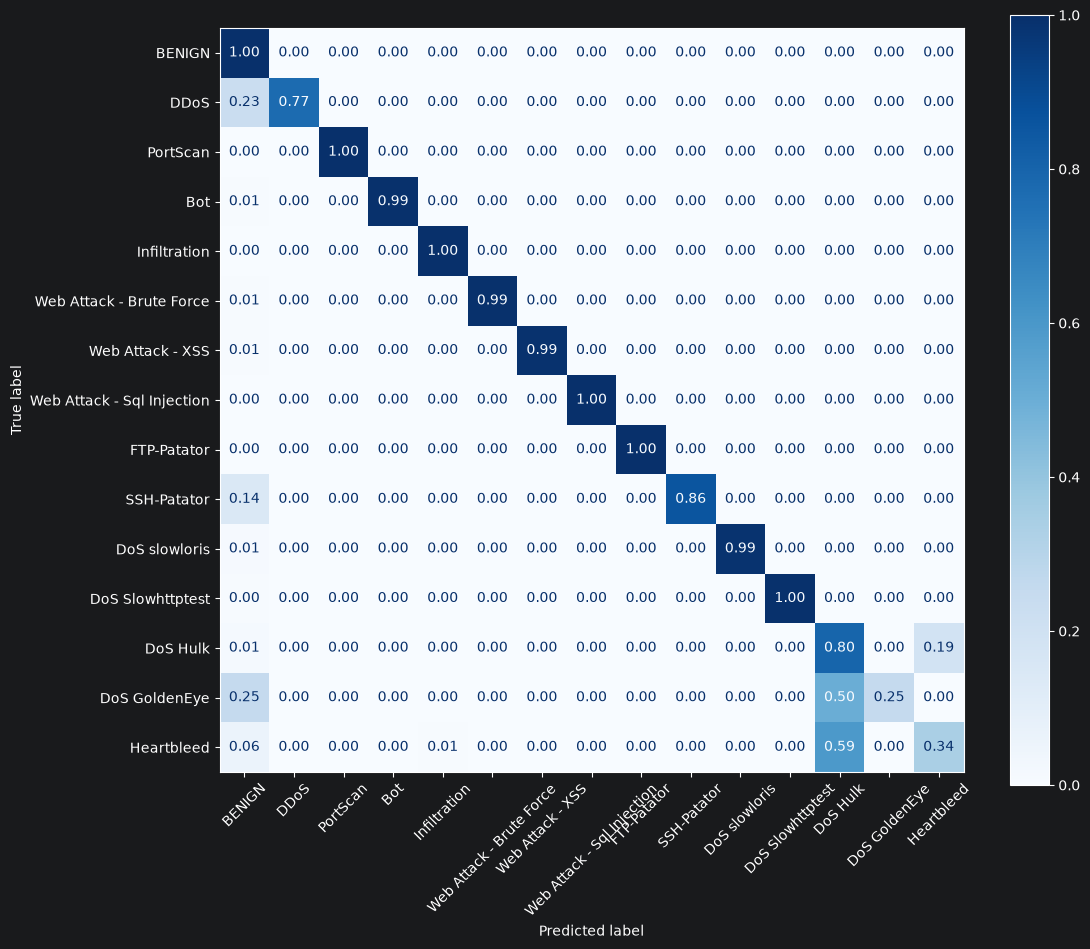

In [8]:
plt_path = Path('../out/plots/')
plt_path.mkdir(exist_ok=True, parents=True)

y_pred = model.predict(x_test)
labels = df['Label'].values.unique()
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred, target_names=labels)
cm = confusion_matrix(y_test, y_pred, normalize='true')

fig, ax = plt.subplots(figsize=(12, 10))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='.2f', xticks_rotation=45)

print(f"Accuracy: {accuracy:.2f}")
print(f"\nClassification Report:\n {classification_rep}")
plt.savefig(Path(plt_path, 'RF - ConfusionMatrix.png'))
plt.show()

In [9]:
train_pred = model.predict(x_train)
test_pred = model.predict(x_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print(train_acc)
print(test_acc)

0.9997762047021044
0.9982136455848809


In [10]:
print("Training Report")
print(classification_report(y_train, train_pred, target_names=labels))

print("Test Report")
print(classification_report(y_test, test_pred, target_names=labels))

Training Report
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00   1670514
                      DDoS       1.00      1.00      1.00      1558
                  PortScan       1.00      1.00      1.00     99529
                       Bot       1.00      1.00      1.00      7156
              Infiltration       1.00      1.00      1.00    129370
  Web Attack - Brute Force       1.00      1.00      1.00      3864
          Web Attack - XSS       1.00      1.00      1.00      3857
Web Attack - Sql Injection       1.00      1.00      1.00      4741
               FTP-Patator       1.00      1.00      1.00         6
               SSH-Patator       1.00      1.00      1.00        28
             DoS slowloris       1.00      1.00      1.00     72449
          DoS Slowhttptest       1.00      1.00      1.00      2574
                  DoS Hulk       1.00      1.00      1.00      1176
             DoS GoldenEye     

From above, it does not seem like the model is overfitting, but rather that we don't have enough data, but the original CICIDS2017 dataset had enough. The problem likely occurred in cleaning. It may have been too aggressive, will need to inspect that.

The above is outdated outcome, the new outcome is relatively better, and the majority of the problem has been solved.

The remaining misclassifications are primarily confined to minority classes (HeartBleed) and semantically similar Denial-Of-Service attacks (GoldenEye and Hulk). These errors are likely because of class imbalance.

In [11]:
# model.save('../out/models/random-forest_1.0.joblib')